[pystran](https://github.com/PetrKryslUCSD/pystran) - Python package for structural analysis with trusses and beams

(C) 2025-2026, Petr Krysl, pkrysl@ucsd.edu

# Spatial frame with a hinge and spring supports

Last updated: 07/12/26

## Problem description

Structure consisting of two L-shaped members connected by a spherical ball joint
(hinge), and supported partially by extension and torsion springs at the two
extremities. A static solution is sought for loading at one of the corner joints.

Displacements and internal forces are provided in the verification manual.

## References

This is the AFNOR SSLL04/89 test case.

Original source: "Guide de validation des progiciels de calcul de structures"
publié par l'AFNOR 1990 (ISBN 2-12-486611-7).

Data taken from: ICAB Force Exemples Exemples de calculs de statique pour ICAB
Force. www.icab.fr

## Documentation

[pystran docs](https://petrkryslucsd.github.io/pystran)


We begin with the standard imports:

In [166]:
from numpy import array
import context
from pystran import model
from pystran import section
from pystran import plots
from pystran import beam

In [167]:
E = 2.1e11  # N/m^2
nu = 1 / 3
G = E / (2 * (1 + nu))
A = 1e-3  # m^2
Iz = 1e-6  # m^4
Iy = 1e-6  # m^4
Ix = 2e-6  # m^4
J = Ix  # Torsional constant
K = 52500  # N/m (translation spring) or N/m*m (rotation spring)
F = 10000

The model is created as three dimensional.


In [168]:
m = model.create(3)
freedoms = m["freedoms"]

Joints are added at their locations. The original source refers to the nodes
(joints) as `N_A`, `N_B`, etc. `N_A` and `N_B` are supported, `N_H1` and `N_H2` are 
two joints at the same location that are linked to form a hinge.


In [169]:
jA = model.add_joint(m, "N_A", [0.0, 2.0, 1.0])
jB = model.add_joint(m, "N_B", [2.0, 0.0, -1.0])
model.add_joint(m, "N_C", [0.0, 0.0, -1.0])
model.add_joint(m, "N_D", [0.0, 0.0, +1.0])
model.add_joint(m, "N_H1", [0.0, 0.0, 0.0]) # the same location
model.add_joint(m, "N_H2", [0.0, 0.0, 0.0]) # the same location


{'jid': 'N_H2', 'coordinates': array([0., 0., 0.])}

The ground is represented as joint, which we will make immovable below.


In [170]:
ground = model.add_joint(m, "ground", [2.0, 2.0, 0.0])

There are four beams. The cross sectional properties are the same, but the
beam orientations need to be different.

In [171]:
# Beams along the Z-axis.
xz_vector = [1, 0, 0]
sect_1 = section.beam_3d_section(
    "sect_1", E=E, G=G, A=A, Ix=Ix, Iy=Iy, Iz=Iz, J=J, xz_vector=xz_vector
)
# Beams along the X- and Y-axis.
xz_vector = [0, 0, 1]
sect_2 = section.beam_3d_section(
    "sect_2", E=E, G=G, A=A, Ix=Ix, Iy=Iy, Iz=Iz, J=J, xz_vector=xz_vector
)

With the above definitions of the sections at hand, we define the four beam
members.

In [172]:
model.add_beam_member(m, 1, ["N_A", "N_D"], sect_2)
model.add_beam_member(m, 2, ["N_C", "N_B"], sect_2)
model.add_beam_member(m, 3, ["N_D", "N_H1"], sect_1)
model.add_beam_member(m, 4, ["N_H2", "N_C"], sect_1)

{'mid': 4,
 'connectivity': ['N_H2', 'N_C'],
 'section': {'name': 'sect_1',
  'E': 210000000000.0,
  'G': 78750000000.0,
  'rho': 0.0,
  'CTE': 0.0,
  'A': 0.001,
  'Ix': 2e-06,
  'Iy': 1e-06,
  'Iz': 1e-06,
  'J': 2e-06,
  'xy_vector': None,
  'xz_vector': array([1, 0, 0])}}

Now we can plot the geometry of the structure. We show the members,
the member numbers, and the orientations of the local coordinate systems.

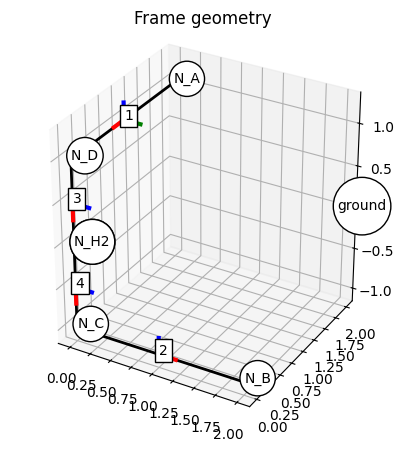

In [173]:
ax = plots.setup(m)
plots.plot_members(m)
plots.plot_member_ids(m)
plots.plot_joint_ids(m)
plots.plot_member_orientation(m, 0.20)
ax.set_title("Frame geometry")
plots.show(m)

Next we add the link between the two joints that form the hinge. The hinge is
a ball joint, meaning all three translations are the same for the two joints at the
hinge.


In [174]:
model.add_dof_links(m, ["N_H1", "N_H2"], freedoms.U1)
model.add_dof_links(m, ["N_H1", "N_H2"], freedoms.U2)
model.add_dof_links(m, ["N_H1", "N_H2"], freedoms.U3)

The supports are next. The original source refers to the supports at `N_A` and
`N_B`.


In [175]:
model.add_support(jA, freedoms.U1)
model.add_support(jA, freedoms.U3)
model.add_support(jA, freedoms.UR2)

In [176]:
model.add_support(jB, freedoms.U2)
model.add_support(jB, freedoms.U3)
model.add_support(jB, freedoms.UR1)

The ground "joint" is fully supported.


In [177]:
model.add_support(ground, freedoms.ALL_DOFS)

Next we add the springs to the ground. The translation and rotation spring
constants have the same numerical value. First at joint `N_A`.


In [178]:
model.add_spring_member(
    m,
    1,
    ["N_A", "ground"],
    section.spring_section("EXT_A", "extension", [0, 1, 0], K),
)
model.add_spring_member(
    m,
    2,
    ["N_A", "ground"],
    section.spring_section("TOR_A_X", "torsion", [1, 0, 0], K),
)
model.add_spring_member(
    m,
    3,
    ["N_A", "ground"],
    section.spring_section("TOR_A_Z", "torsion", [0, 0, 1], K),
)


{'mid': 3,
 'connectivity': ['N_A', 'ground'],
 'section': {'name': 'TOR_A_Z',
  'kind': 'torsion',
  'direction': [0, 0, 1],
  'stiffness_coefficient': 52500},
 'dofkind': (3, 4, 5)}

Then at joint `N_B`.


In [179]:
model.add_spring_member(
    m,
    4,
    ["N_B", "ground"],
    section.spring_section("EXT_B", "extension", [1, 0, 0.0], K),
)
model.add_spring_member(
    m,
    5,
    ["N_B", "ground"],
    section.spring_section("TOR_B_Y", "torsion", [0, 1, 0], K),
)
model.add_spring_member(
    m,
    6,
    ["N_B", "ground"],
    section.spring_section("TOR_B_Z", "torsion", [0, 0, 1], K),
)

{'mid': 6,
 'connectivity': ['N_B', 'ground'],
 'section': {'name': 'TOR_B_Z',
  'kind': 'torsion',
  'direction': [0, 0, 1],
  'stiffness_coefficient': 52500},
 'dofkind': (3, 4, 5)}

Let us look at the translation and rotation supports. Note  the support of the ground "joint".



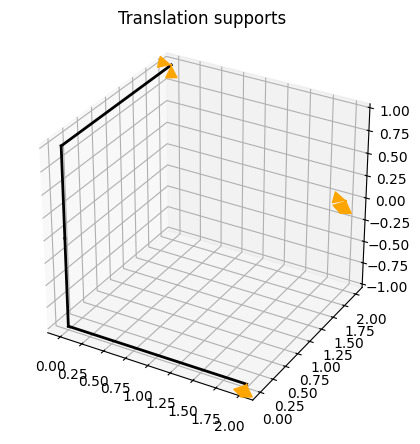

In [180]:
ax = plots.setup(m)
plots.plot_members(m)
# plots.plot_joint_ids(m)
plots.plot_translation_supports(m)
ax.set_title("Translation supports")
plots.show(m)

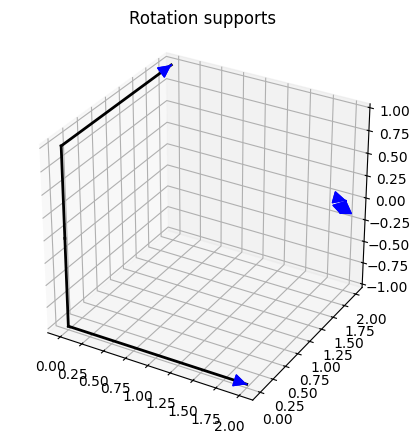

In [181]:
ax = plots.setup(m)
plots.plot_members(m)
# plots.plot_joint_ids(m)
plots.plot_rotation_supports(m)
ax.set_title("Rotation supports")
plots.show(m)

Next we add the forces and moments applied at the joint N_D.


In [182]:
model.add_load(m["joints"]["N_D"], freedoms.U3, -F)

Now we can solve the static equilibrium of the frame.


In [183]:
model.number_dofs(m)
model.solve_statics(m)

The solution to the problem can be visualized with a number of plots. We start
with the deformed shape of the frame.


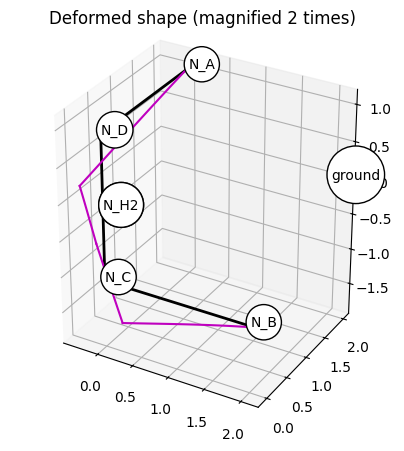

In [184]:
ax = plots.setup(m)
plots.plot_members(m)
plots.plot_joint_ids(m)
ax = plots.plot_deformations(m, 2.0)
ax.set_title("Deformed shape (magnified 2 times)")
plots.show(m)

These are the displacements at all the joints.


In [185]:
for j in m["joints"].values():
    print(j["jid"], ": ", j["displacements"])

N_A :  [ 0.         -0.02976196  0.          0.16072649  0.         -0.05951626]
N_B :  [ 0.02975813  0.          0.          0.         -0.16070581 -0.05952392]
N_C :  [ 0.02977301  0.13888914 -0.37002052 -0.01984131 -0.19344272 -0.0744049 ]
N_D :  [-0.13887127 -0.02977684 -0.37006814  0.19346762  0.01983875 -0.07439533]
N_H1 :  [-0.16118987  0.16121061 -0.37004433  0.18974737  0.02355852 -0.07439533]
N_H2 :  [-0.16118987  0.16121061 -0.37004433 -0.02356155 -0.18972296 -0.0744049 ]
ground :  [0. 0. 0. 0. 0. 0.]


The displacements of the joints can be compared to the reference values.
These are the displacements of joint 1:


In [186]:
ref1 = array([0.0, -0.02976196, 0.0, 0.16072649, 0.0, -0.05951626])
for i in range(6):
    if abs(jA["displacements"][i] - ref1[i]) > 0.001 * abs(ref1[i]):
        raise ValueError("Displacement calculation error")

These are the displacements of joint 3:


In [187]:
ref3 = array([0.02977301, 0.13888914, -0.37002052])
for i in range(3):
    if abs(m["joints"]["N_C"]["displacements"][i] - ref3[i]) > 0.001 * abs(ref3[i]):
        raise ValueError("Displacement calculation error")

In [188]:
print("Displacement calculation OK")

Displacement calculation OK


Moment diagrams can be produced for the torsional and bending moments in the
members.


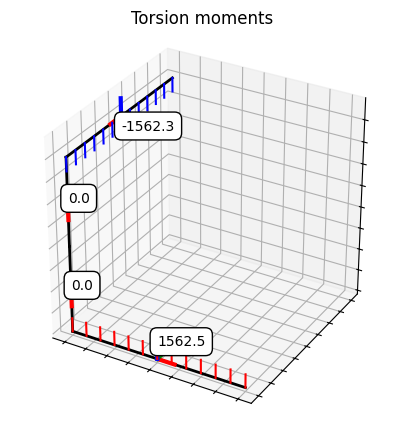

In [189]:
ax = plots.setup(m)
plots.plot_members(m)
# plots.plot_joint_ids(m)
plots.plot_member_orientation(m, 0.2)
ax = plots.plot_torsion_moments(m, scale=0.0001)
ax.set_title("Torsion moments")
plots.show(m)

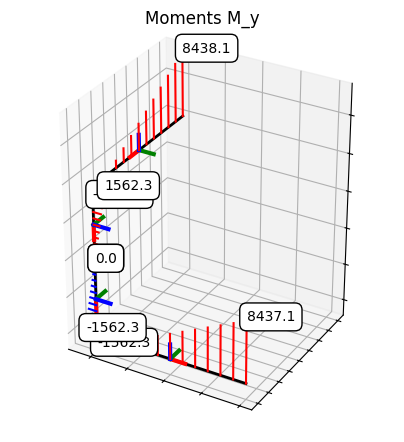

In [190]:
ax = plots.setup(m)
plots.plot_members(m)
# plots.plot_joint_ids(m)
plots.plot_member_orientation(m, 0.2)
ax = plots.plot_bending_moments(m, scale=0.0001, axis="y")
ax.set_title("Moments M_y")
plots.show(m)

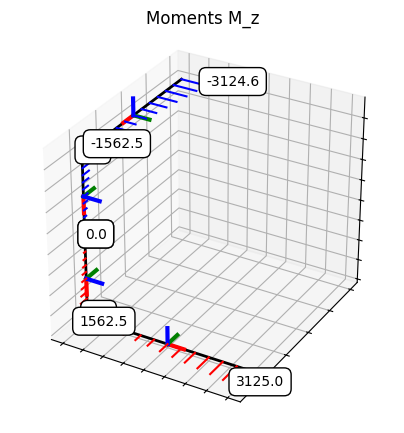

In [191]:
ax = plots.setup(m)
plots.plot_members(m)
# plots.plot_joint_ids(m)
plots.plot_member_orientation(m, 0.2)
ax = plots.plot_bending_moments(m, scale=0.0001, axis="z")
ax.set_title("Moments M_z")
plots.show(m)

The internal "end forces", i.e., the forces and moments at the ends of the
members that act on the joints, are reported.


In [192]:
for k in m["beam_members"].keys():
    member = m["beam_members"][k]
    connectivity = member["connectivity"]
    i, j = m["joints"][connectivity[0]], m["joints"][connectivity[1]]
    f = beam.beam_3d_end_forces(member, i, j)
    print(f"Member {k}: ")
    print(f"   Joint {connectivity[0]}: ")
    print(f"   N={f['Ni']:.5}, Qy={f['Qyi']:.5}, Qz={f['Qzi']:.5}")
    print(f"   T={f['Ti']:.5}, My={f['Myi']:.5}, Mz={f['Mzi']:.5}")
    print(f"   Joint {connectivity[1]}: ")
    print(f"   N={f['Nj']:.5}, Qy={f['Qyj']:.5}, Qz={f['Qzj']:.5}")
    print(f"   T={f['Tj']:.5}, My={f['Myj']:.5}, Mz={f['Mzj']:.5}")

Member 1: 
   Joint N_A: 
   N=1562.5, Qy=-1562.3, Qz=-5000.3
   T=-1562.3, My=8438.1, Mz=-3124.6
   Joint N_D: 
   N=-1562.5, Qy=1562.3, Qz=5000.3
   T=1562.3, My=1562.5, Mz=-0.0
Member 2: 
   Joint N_C: 
   N=-1562.3, Qy=-1562.5, Qz=4999.7
   T=1562.5, My=-1562.3, Mz=0.0
   Joint N_B: 
   N=1562.3, Qy=1562.5, Qz=-4999.7
   T=-1562.5, My=-8437.1, Mz=-3125.0
Member 3: 
   Joint N_D: 
   N=-4999.7, Qy=-1562.5, Qz=-1562.3
   T=0.0, My=1562.3, Mz=-1562.5
   Joint N_H1: 
   N=4999.7, Qy=1562.5, Qz=1562.3
   T=-0.0, My=-5.8287e-12, Mz=-2.3315e-11
Member 4: 
   Joint N_H2: 
   N=-4999.7, Qy=-1562.5, Qz=-1562.3
   T=0.0, My=-0.0, Mz=0.0
   Joint N_C: 
   N=4999.7, Qy=1562.5, Qz=1562.3
   T=-0.0, My=1562.3, Mz=-1562.5


The reference provides values of moments at joint N_A in member 1:


In [193]:
member = m["beam_members"][1]
connectivity = member["connectivity"]
i, j = m["joints"][connectivity[0]], m["joints"][connectivity[1]]
f = beam.beam_3d_end_forces(member, i, j)
if abs(f["Ti"] - -1562.3) > 1e-1:
    raise ValueError("Member 1, joint i, internal moment error")
if abs(f["Myi"] - 8438.1) > 1e-1:
    raise ValueError("Member 1, joint i, internal moment error")
if abs(f["Mzi"] - -3124.6) > 1e-1:
    raise ValueError("Member 1, joint i, internal moment error")

## Conclusions

This frame may look peculiar, but it is carefully constructed so that an analytical solution can be found. Our numerical solution can then be compared with the analytical one.